# Exercise 1: K-Nearest Neighbors on Moons Dataset

Apply the k-nearest neighbors algorithm on the moons dataset. The number of samples of this dataset is 200. Split the data such that the test split is 45% of the initial dataset. Set the number of neighbors parameter to 2 and compute the accuracy on the test set. Visualize the decision boundary of the KNN classifiers using different values for k = {1,5,9}.

In [97]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [98]:
# dataset with the correct number of samples
# daca bagam noise aici se schimba situatia
X, y = make_moons(n_samples = 200,
                  # noise =  0.15
                  random_state = 42)

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.45,
                                                    random_state = 42)

In [100]:
clf = KNeighborsClassifier(n_neighbors = 2)
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [101]:
# asta nu e cerut
clf.predict(X_test)

array([1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0])

In [102]:
accuracy = clf.score(X_test, y_test)
print("Accuracy : ", accuracy)

Accuracy :  1.0


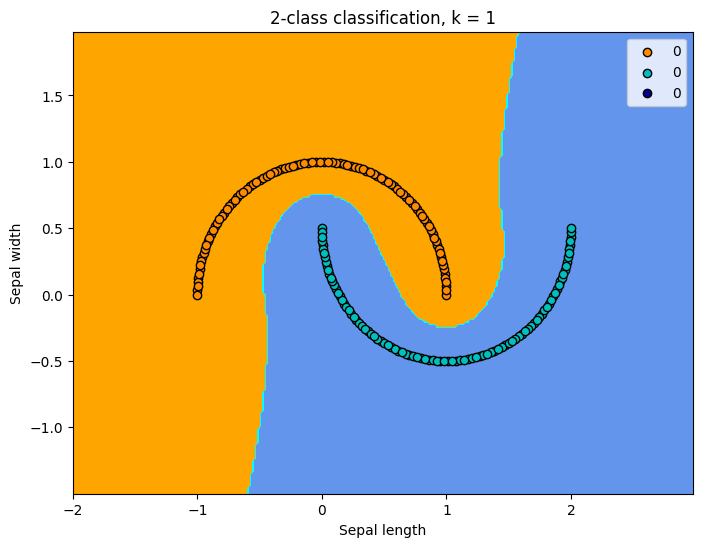

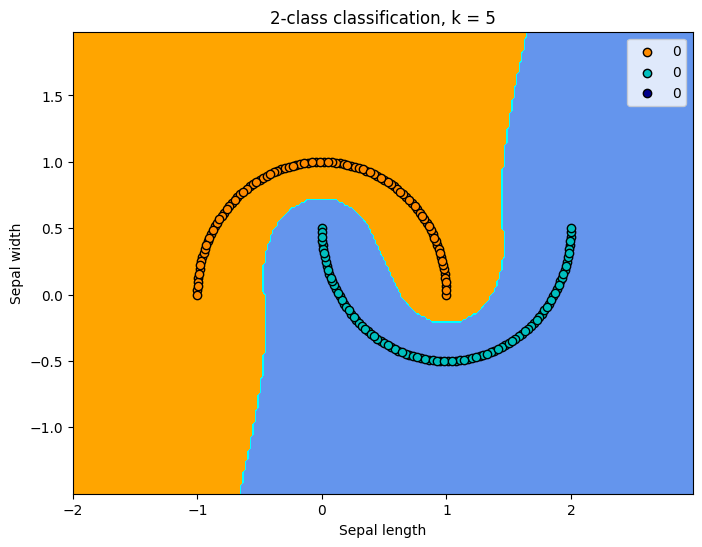

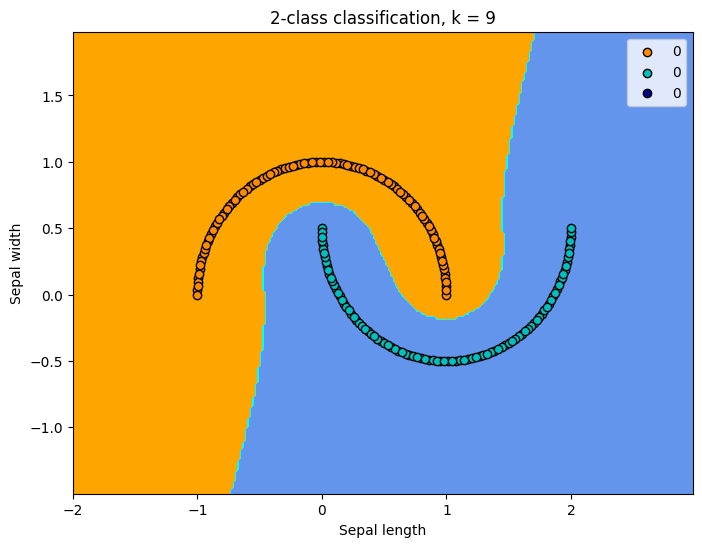

In [103]:
h = 0.02  # Step size in the mesh

# Create color maps
cmap_light = ListedColormap(["orange", "cyan", "cornflowerblue"])
cmap_bold = ["darkorange", "c", "darkblue"]

for n_neighbors in [1, 5, 9]:
    # We create an instance of KNeighborsClassifier and fit the data.
    clf = KNeighborsClassifier(n_neighbors)
    clf.fit(X, y)

    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points
    for i in range(3):
      plt.scatter(X[:, 0][y==i], X[:, 1][y==i], c=cmap_bold[i],
                  edgecolors="black", label=y[i])

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("2-class classification, k = %i" % (n_neighbors))
    plt.xlabel("Sepal length")
    plt.ylabel("Sepal width")
    plt.legend()

plt.show()

# Exercise 2: Nonlinear SVM Classification

Use the following dataset:
```python
X1, y1 = make_gaussian_quantiles(cov=7., n_samples=250, n_features=2, n_classes=3, random_state=1)
```

Apply the nonlinear SVM classification. Use the polynomial kernel with degree = 3, coef0 = 10, C = 5, respectively. Plot the decision boundary of the nonlinear SVM classification.

In [104]:
from sklearn.datasets import make_gaussian_quantiles
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

In [105]:
X, y = make_gaussian_quantiles(cov = 7.,
                                 n_samples = 250,
                                 n_features = 2,
                                 n_classes = 3,
                                 random_state = 1)

In [106]:
poly_kernel_svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="poly", degree = 3, coef0 = 10, C=5))
    ])

poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=10, kernel='poly'))])

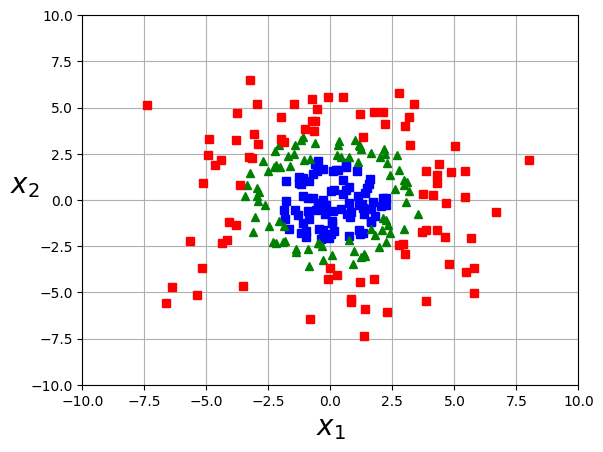

In [107]:
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.plot(X[:, 0][y==2], X[:, 1][y==2], "rs")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

plot_dataset(X, y, [-10, 10, -10, 10])
plt.show()

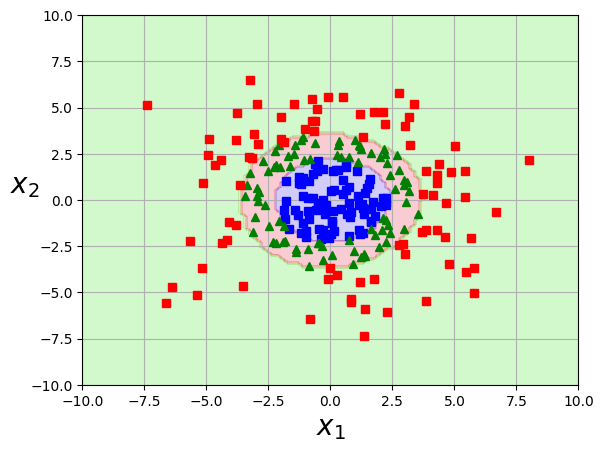

In [108]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

plot_predictions(poly_kernel_svm_clf, [-10, 10, -10, 10])
plot_dataset(X, y, [-10, 10, -10, 10])

plt.show()

# Exercise 3: Linear SVM Regression

Apply linear SVM regression to the following dataset:
```python
X = 6 * np.random.rand(n, 1)
y = (1 - 2 * X + np.random.randn(n, 1)).ravel()
```

Set the width of the margin to 0.8 and plot the fit line.

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVR

In [110]:
np.random.seed(42)
n = 50

In [111]:
X = 6 * np.random.rand(n, 1)
y = (1 - 2 * X + np.random.randn(n, 1)).ravel()

In [112]:
# epsilon = width of the margin
svm_reg = LinearSVR(epsilon=0.8, random_state=42)

svm_reg.fit(X, y)

LinearSVR(epsilon=0.8, random_state=42)

In [113]:
def find_support_vectors(svm_reg, X, y):
    y_pred = svm_reg.predict(X)
    off_margin = (np.abs(y - y_pred) >= svm_reg.epsilon)
    return np.argwhere(off_margin)

svm_reg.support_ = find_support_vectors(svm_reg, X, y)


In [114]:
def plot_svm_regression(svm_reg, X, y, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(100, 1)

    y_pred = svm_reg.predict(x1s)

    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$")
    plt.plot(x1s, y_pred + svm_reg.epsilon, "k--")
    plt.plot(x1s, y_pred - svm_reg.epsilon, "k--")

    plt.scatter(X[svm_reg.support_], y[svm_reg.support_], s=200, facecolors='#FFAAAA')

    plt.plot(X, y, "bo")
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.legend(loc="upper left", fontsize=18)

    plt.axis(axes)

Text(0, 0.5, '$y$')

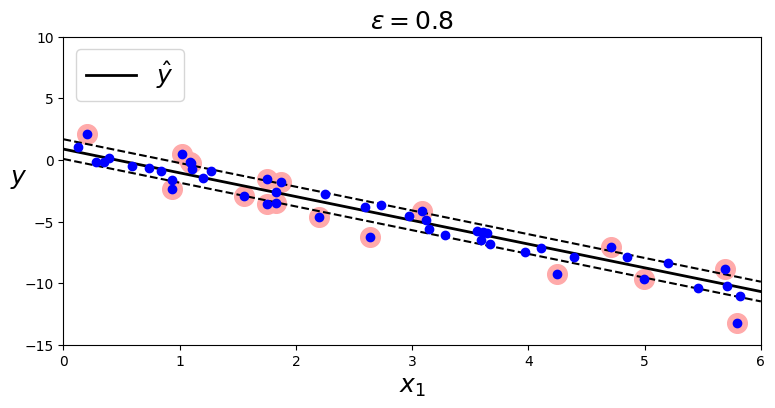

In [115]:
fig, axes = plt.subplots(ncols=1, figsize=(9, 4))
plt.sca(axes)
plot_svm_regression(svm_reg, X, y, [0, 6, -15, 10])
plt.title(r"$\epsilon = {}$".format(svm_reg.epsilon), fontsize=18)
plt.ylabel(r"$y$", fontsize=18, rotation=0)